In [1]:
import spot
from spot.jupyter import display_inline
spot.setup()

Representation of ω-automata with state-based acceptance using MTBDDs.  

We initially implemented a transition-based variant, before realizing that using MTBDDs, the transition-based and state-based versions of an automaton have exactly the same structure, the state-based version is even slightly more memory efficient.

So even if the transition-based variant still exists (see the [mtdtwa.ipynb notebook](mtdtwa.ipynb)), its state-based counterpart, presented here, is much more developed.

# Multi-Terminal-BDD-based Deterministic State-based ω-Automaton (MTDSwA)

The MTBDD-based representation of these automata is very close to Mona's DFA representation.  An `mtdswa` is just a pair of arrays indexed by state numbers.  The value of `states[i]` is an MTBDD encoding the successors states of state `i`, with terminal containing state indices.  The value of `colors[i]` gives the set of colors associated to state `i`.  

Compared to `mtdtwa`, the set of MTBDD nodes needed to represent a `mtdswa` is not bigger than the one used to represent an `mtdtwa` as states that have different colors but behave the same will share their MTBDD.   This representation seems much easier to work with.

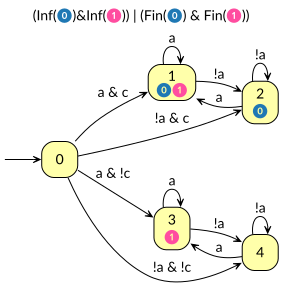

In [2]:
a2 = spot.translate("GFa <-> c", "generic", "deterministic", "SBAcc")
a2

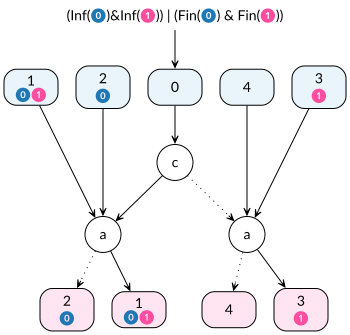

In [3]:
m2 = spot.dtwa_to_mtdswa(a2)
display(m2)

In [4]:
for i, d in enumerate(m2.colors):
    print(f"colors[{i}] = {d}")

colors[0] = {}
colors[1] = {0,1}
colors[2] = {0}
colors[3] = {1}
colors[4] = {}


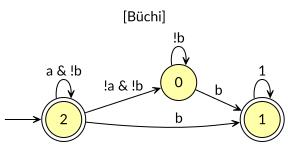

In [5]:
a3 = spot.translate("Ga | Fb")
a3

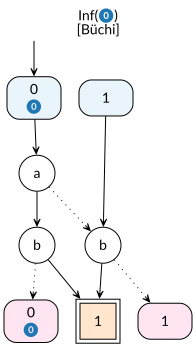

In [6]:
m3 = spot.dtwa_to_mtdswa(a3)
m3

In [7]:
display_inline(m3.as_twa(), m3.as_twa(True))

In [8]:
display_inline(m2.as_twa(), m2.as_twa(True))

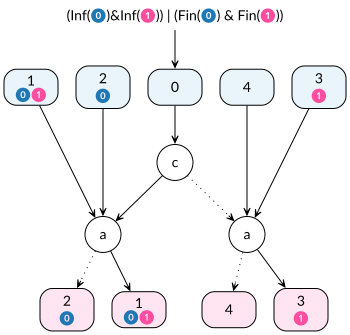

In [9]:
m2

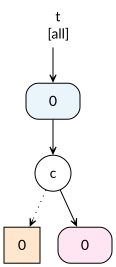

In [10]:
i1 = spot.dtwa_to_mtdswa(spot.translate("G(c)", "det")); i1

When using `as_twa()`, the third argument allow to chose between incomplete (rejecting sinks are removed) and complete (rejecting sinks are added) TwA.  Adding sinks may require to change the acceptance condition.

In [11]:
i1i = i1.as_twa(True, False, False)
i1c = i1.as_twa(True, False, True)
display_inline(i1i, i1i.prop_complete(), i1c, i1c.prop_complete())

# SCC computations

The `scc_vector` assigne each state to the index of a maximal SCC ordered topologically (each SCC can only reach SCC with smaller indices).

The computation is performed in Linear time by considering the mtdswa as an oriented graph.  Passing option 's' to `show()` will highlight non-trivial SCCs (including their states and MTBDD nodes).

In [12]:
spot.scc_vector(m2)

(2, 1, 1, 0, 0)

In [13]:
spot.scc_vector(m3)

(1, 0)

In [14]:
m2.show("s")

In [15]:
m3.show("s")

In [16]:
a = spot.translate("(a U b) | XG(c)", "det")
m4 = spot.dtwa_to_mtdswa(a)
print(spot.scc_vector(m4))
m4.show('s')

(3, 0, 2, 1)


In [17]:
a = spot.translate("(a U b) & GFa & GFb & FGc", "det", "sbacc", "gen")
m5 = spot.dtwa_to_mtdswa(a)
m5.show('s')

**TODO**: The linking above is not optimal.  Since all states 1,2,3,4,5 recognize the same language, it would be better to always jump on the same state when entering this SCC.  That way the two transient "b" node above false could be merged.  Currently we don't care too much because those nodes were converted from an explicit representation.  However, when we start building translating LTL to mtdswa directly, we can probably do better.

The `false` and `true` automata don't display very well because they have to introduce a state that points to the constant.  But that should be interpreted as a single SCC.  (Technically, the blue nodes at the top of the figures do not really belong to the SCCs.)

In [18]:
a = spot.translate("true", "det")
m5 = spot.dtwa_to_mtdswa(a)
print(spot.scc_vector(m5))
m5.show('s')

(0,)


# Translation from obligation formula to Deterministic Weak BA 

... represented as MTDSWA.

The translation rules are even simpler than those of for translating LTLf to MTDFA (see the [CIAA'25 paper](https://www.lrde.epita.fr/~adl/dl/adl/duret.25.ciaa.pdf) or the [ltlf2dfa notebook](https://spot.lre.epita.fr/ipynb/ltlf2dfa.html)).   

Let us use $\boxed{\varphi}$ to denote a terminal labeled by LTL formula $\varphi$.  Let us further assume that applying any Boolean operator $\odot\in\{\land,\lor,\leftarrow,\leftrightarrow,\oplus,...\}$ between two terminals results in a terminal labeled by the result of applying $\odot$ on the two labels, i.e., $\boxed{\alpha}\odot\boxed{\beta}=\boxed{\alpha\odot\beta}$.  Using that convention, the standard apply2() operation of BDD can be extended to support Boolean operation on MTBDD labeled by LTL formulas.

Then the translation of an LTL formula to MTBDD with LTL terminals following the standard expansion rules of LTL:

\begin{align}
   \mathit{tr}(b) &= \text{BDD representation of $b$}& \text{for any Boolean formula $b$} \\
   \mathit{tr}(\mathop{\mathsf{X}}\varphi) &= \boxed{\varphi} \\
   \mathit{tr}(\lnot\varphi) &= \lnot\mathit{tr}(\varphi) \\
   \mathit{tr}(\alpha \odot \beta) &= \mathit{tr}(\alpha)\odot \mathit{tr}(\beta) & \text{for any Boolean operator $\odot\in\{\land,\lor,\leftarrow,\leftrightarrow,\oplus,...\}$}\\
   \mathit{tr}(\alpha \mathbin{\mathsf{U}} \beta) &= \mathit{tr}(\beta)\lor(\mathit{tr}(\alpha)\land\boxed{\alpha \mathbin{\mathsf{U}} \beta}) \\
   \mathit{tr}(\alpha \mathbin{\mathsf{W}} \beta) &= \mathit{tr}(\beta)\lor(\mathit{tr}(\alpha)\land\boxed{\alpha \mathbin{\mathsf{W}} \beta}) \\
   \mathit{tr}(\alpha \mathbin{\mathsf{M}} \beta) &= \mathit{tr}(\beta)\land(\mathit{tr}(\alpha)\lor\boxed{\alpha \mathbin{\mathsf{M}} \beta}) \\
   \mathit{tr}(\alpha \mathbin{\mathsf{R}} \beta) &= \mathit{tr}(\beta)\land(\mathit{tr}(\alpha)\lor\boxed{\alpha \mathbin{\mathsf{R}} \beta}) \\
   \mathit{tr}(\mathop{\mathsf{F}} \varphi) &= \mathit{tr}(\varphi)\lor\boxed{\mathop{\mathsf{F}}\varphi} \\
   \mathit{tr}(\mathop{\mathsf{G}} \varphi) &= \mathit{tr}(\varphi)\land\boxed{\mathop{\mathsf{G}}\varphi} \\
\end{align}

The above rules for $\mathit{tr}(\varphi)$ can be used to obtain the MTBDD representing the outgoing edges of a state $\varphi$.   By iterating this for all formulas that label terminals reachable from $\varphi$, we can build the structure of the automaton for $\varphi$.

For termination, each formulas that appear in terminal are assumed to be replaced by one unique representative of their propositional equivalence classes.  See [the ltlf2dfa notebook](https://spot.lre.epita.fr/ipynb/ltlf2dfa.html#Propositional-equivalence) for details.

What remains is to decide for each state whether it is accepting.  The $\lambda$ function below does that by just checking the top-level temporal operators.  That states labeled by strong operators ($\mathsf{F}$, $\mathsf{U}$, $\mathsf{M}$) should not be accepting, and states labeled by weak operators ($\mathsf{G}$, $\mathsf{W}$, $\mathsf{R}$) should be accepting.  Combinations of those follow the semantics of the Boolean operators.

\begin{align}
    \lambda(\top)&=\top\\
    \lambda(\bot)&=\bot\\
    \lambda(a) &= * & \text{for any atomic proposition}\\
    \lambda(\lnot\varphi) &= \lnot\lambda(\varphi)\\
    \lambda(\mathop{\mathsf{X}}\varphi) &= \lambda(\varphi) \\
    \lambda(\alpha \odot \beta) &= \lambda(\alpha)\odot\lambda(\beta) & \text{for any Boolean operator $\odot\in\{\land,\lor,\leftarrow,\leftrightarrow,\oplus,...\}$} \\
    \lambda(\alpha \mathbin{\mathsf{U}} \beta) &= \bot \\
    \lambda(\alpha \mathbin{\mathsf{M}} \beta) &= \bot \\
    \lambda(\mathop{\mathsf{F}}\varphi) &= \bot \\
    \lambda(\alpha \mathbin{\mathsf{W}} \beta) &= \top \\
    \lambda(\alpha \mathbin{\mathsf{R}} \beta) &= \top \\
    \lambda(\mathop{\mathsf{G}}\varphi) &= \top \\
\end{align}

Here the value $*$ should be interpreted as a joker that can simply be ignored when being combined with other Boolean operations:
\begin{align}
  \top\land * &= \top   & \bot \land * &= \bot  & * \land * &= * \\ 
  \top\lor *  &= \top   & \bot \lor *  &= \bot  & * \lor *  &= * \\
  \top\rightarrow * &= \bot & \bot \rightarrow * &= \top & * \rightarrow * &= * &
  * \rightarrow \top &= \top & * \rightarrow \bot &= \bot & \\
  \top\leftrightarrow * &= \top & \bot \leftrightarrow * &= \top & * \leftrightarrow * &= * \\
  \top\oplus * &= \top & \bot \oplus * &= \top & * \oplus * &= * \\
               &        &              &       &         \lnot * &= * 
\end{align}

By construction, one can see that the only formulas $\varphi$ for which $\lambda(\varphi)=*$ must be obtained by using only atomic propositions, Boolean operators and $\mathop{\mathsf{X}}$ operators, this corresponds to formulas that are both safety and co-safety syntactically.  If such a formula labels a state, that state cannot be part of any cycle, i.e., it is a transient state, and its acceptance is irrelevant.  Hence the use of a joker.

For the construction, states labeled by a formula $\varphi$ such that $\lambda(\varphi)=\top$ should be tagged as accepting, states where $\lambda(\varphi)=\bot$ must be tagged as rejecting, and states for which $\lambda(\varphi)=*$ can be tagged either way without impact on the language.

In the implementation we do not actually use the above ternary logic.  Instead we have $\lambda(a)=\bot$, and the Boolean operators (which are n-ary in the case of $\land$ and $\lor$) are modified to ignore the arguments that are both safety and co-safety syntactically (Spot maintains this class membership as a property bit in each formula, so this can be tested in constant time).

In [19]:
t1 = spot.obligation_to_mtdswa('a W b U c')
t1.show('s')

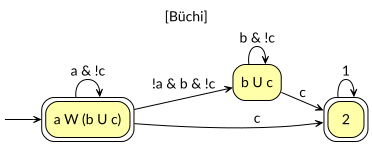

In [20]:
t1.as_twa(True)

In [21]:
t2 = spot.obligation_to_mtdswa('Fa & Fb & Fc')
t2.show('s')

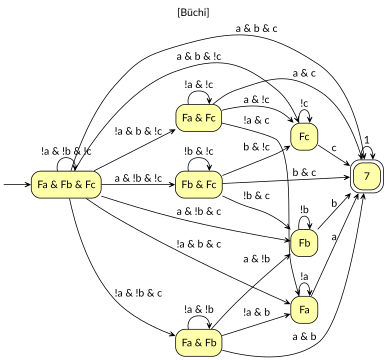

In [22]:
t2.as_twa(True)

In [23]:
t3 = spot.obligation_to_mtdswa('G(p1 <-> X!p1) | F(p0 & Xp1)')
t3.show('s')

In [24]:
t3.as_twa(True).show('.s')

Here is a list of obligation formulas to check that the new translation is equivalent to the old one.

In [25]:
obligations = ['Gp',
               'Fr -> (!p U r)',
               '(!r U (p & !r)) | G!r',
               'Fr -> ((!p & !r) U (r | ((p & !r) U (r | ((!p & !r) U (r | ((p & !r) U (r | (!p U r)))))))))',
               'Fr -> (p U r)',
               'G(q -> Gp)',
               'Fr -> (!p U (r | s))',
               'Fr -> ((p -> (!r U (!r & s))) U r)',
               'Fp -> (!p U (!p & s & X(!p U t)))',
               'Fr -> (!p U (r | (!p & s & X(!p U t))))',
               'F(s & XFt) -> (!s U p)',
               'Fr -> (!(!r & s & X(!r U (!r & t))) U (p | r))',
               'Fr -> ((p -> (!r U (!r & s & X(!r U t)))) U r)',
               'Fr -> ((p -> (!r U (!r & s & !z & X((!r & !z) U t)))) U r)',
               'Fp',
               'G!q | F(q & Fp)',
               '(!p U s) | Gp',
               'Fr -> (((s & X(!r U t)) -> X(!r U (t & Fp))) U r)',
               'G(p1 <-> X!p1) | F(p0 & Xp1)',
               'Ga W Gb', # <- can trigger an infinite loop if propositional equivalence is not done
               ]
for obl in obligations:
    t1 = spot.obligation_to_mtdswa(obl).as_twa(True)    # non-minimized, via MTBDDs
    t2 = spot.translate(obl, 'deterministic', xargs='new-oblig=0') # minimized via historical/explicit construction 
    print(t1.num_states(), t2.num_states(), spot.are_equivalent(t1, t2), obl)

1 1 True Gp
3 3 True Fr -> (!p U r)
2 2 True (!r U (p & !r)) | G!r
7 7 True Fr -> ((!p & !r) U (r | ((p & !r) U (r | ((!p & !r) U (r | ((p & !r) U (r | (!p U r)))))))))
3 3 True Fr -> (p U r)
2 2 True G(q -> Gp)
3 3 True Fr -> (!p U (r | s))
3 3 True Fr -> ((p -> (!r U (!r & s))) U r)
3 3 True Fp -> (!p U (!p & s & X(!p U t)))
4 4 True Fr -> (!p U (r | (!p & s & X(!p U t))))
3 3 True F(s & XFt) -> (!s U p)
5 4 True Fr -> (!(!r & s & X(!r U (!r & t))) U (p | r))
4 4 True Fr -> ((p -> (!r U (!r & s & X(!r U t)))) U r)
4 4 True Fr -> ((p -> (!r U (!r & s & !z & X((!r & !z) U t)))) U r)
2 2 True Fp
3 3 True G!q | F(q & Fp)
4 4 True (!p U s) | Gp
6 6 True Fr -> (((s & X(!r U t)) -> X(!r U (t & Fp))) U r)
8 7 True G(p1 <-> X!p1) | F(p0 & Xp1)
3 3 True Ga W Gb


Let's look at one case where the new translation produces one extra state compared to the reference implementation (which is already minimized).

In [26]:
f = spot.formula('Fr -> (!(!r & s & X(!r U (!r & t))) U (p | r))')

In [27]:
a = spot.obligation_to_mtdswa(f)
a.show('s')

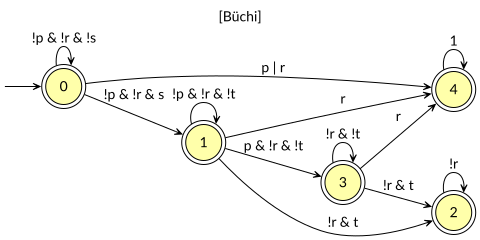

In [28]:
b1 = a.as_twa(True, False)
b1

State 1 and 3 can be merged.  Here is the minimized output from the historical translation.  (If you see `new-oblig=0` appearing in the calls to `translate()` in this notebook, it is because `translate()` was also changed to use the new MTBDD-based obligation translation presented later in this notebook.  Passing `new-oblig=0` forces Spot to use the old non-MTBDD-based obligation translation.)

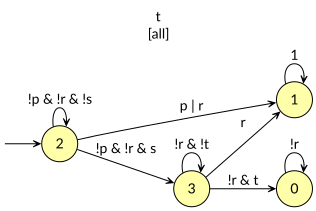

In [29]:
b2 = f.translate('deterministic', xargs='new-oblig=0')
b2

In [30]:
spot.are_equivalent(b1, b2)

True

# Moore's Minimization

Moore's DFA minimization algorithm is easy to implement on MTBDD-based ω-automata, just using the color of the states for the initial partition.  However, despite its name, it does not guarantee a minimal automaton when applied to ω-automata.  (There is a way to fix that for weak deterministic ω-automata, as we will see later.)  Moore's minimization algorithm is quadratic (unlike Hopcroft's which does it in $O(n \log n)$), but it is very suited to MTBDD-based representation because to perform one iteration of the algorithm, we just have to replace each terminal by its current class number, and after rewriting the MTBDDs states the new partition can be read by looking which state have the same MTBDD representation.

The minimization currently forces the `bddtrue` and `bddfalse` terminals in separate classes.  So, for instance, if you build a MTDSWA that contains a `bddtrue` terminal, and another accepting state that loops over itself with label "true", these two states won't be merged.   The minimization for `mtdfa` used to deal with this case, but that made the code more complex and harder to maintain.  In practice, the `bddtrue` and `bddfalse` terminals are only useful during the recursive translation, where they help shortcut BDD operations, but they are more annoying to deal with afterwards.  Hence this implementation of the minimization does not make any effort regarding those.

In a few sections we will show how to change between constant-based (`bddtrue`, `bddfalse`), or state-based representations of sinks.  Therefore, for precise minimization, one should call `a.sinks_as_states()` before `spot.minimize_mtdswa(a)`.

In the meantime, we can still use this algorithm to merge the two equivalent states in automaton `a`:

'before:'

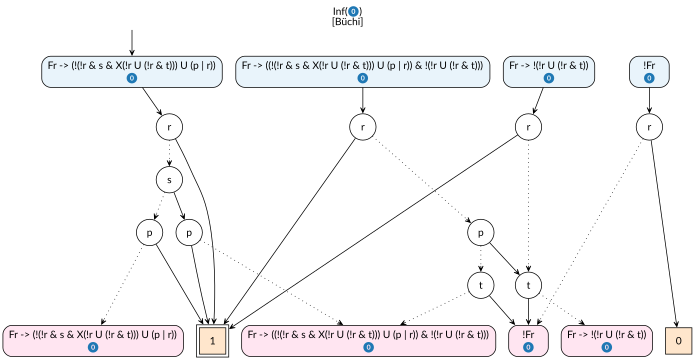

'after:'

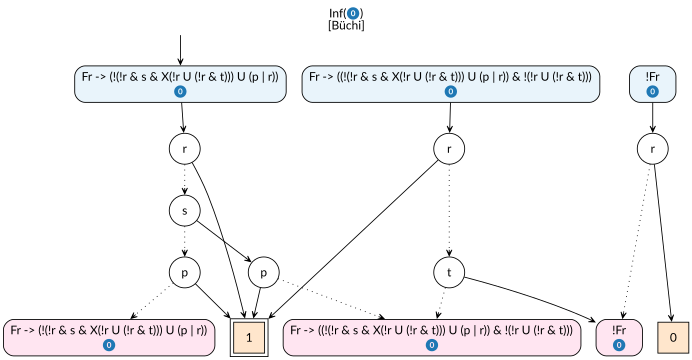

In [31]:
am = spot.minimize_mtdswa(a)
display("before:", a, "after:", am)

In [32]:
spot.are_equivalent(a.as_twa(), am.as_twa())

True

# Löding's preprocessing for weak DBAs

Let's look at a simple example to understand the problem why DFA minimization does not work immediately on weak deterministic ω-automata.

In [33]:
t4 = spot.obligation_to_mtdswa('a | Ga | F(b & Xa)')
t4.show('s')

On this example, we can see that the initial state is labeled by `a | Ga | F(b & Xa)`.  Because this disjunction contains the safety formula `Ga`, the state is marked as accepting.  However, this formula is equivalent to `a | F(b & Xa)`, which would be rejecting.  The different acceptance for those two states is not a threat to the validity of the translation: when the formula `a | Ga | F(b & Xa)` is translated into MTBDD, the superfluous `Ga` naturally disappear, so `a | Ga | F(b & Xa)` only occurs as a transient SCC, and its acceptance has no impact on the language of the automaton.  However, the difference of acceptance prevent those two states from being merged by the DFA minimization algorithm.

In [34]:
spot.minimize_mtdswa(t4).show('s')

An easy fix here would be to detect that `a | Ga | F(b & Xa)` and `a | F(b & Xa)` have the same MTBDD encoding, and because `a | Ga | F(b & Xa)` is a transient state, decide to replace it by the other state.

[Löding's preprocessing](https://doi.org/10.1016/S0020-0190(00)00183-6) is a more general solution that decides for each transient state of a weak deterministic ω-automata whether it should be accepting or rejecting, in such a way that applying DFA minimization on the preprocessed ω-automata will ensure minimality of the result.  Spot implements a variant of this preprocessing that assign to each SCC a rank such that:
- SCCs are accepting iff they have odd rank
- ranks can only decrease along a run of the automaton
- `bddfalse` and `bddtrue` implicitly have rank 0 and 1
- the rank assigned to each SCC is the minimal one that could be assigned given the above constraint.

The way to compute those ranks is quite straight forward and can be done in linear time: compute an SCC decomposition, then process it in a bottom-up way, assigning 0 or 1 to the bottommost depending on its acceptance. Moving up, the rank of a transient state is the maximum of the rank of its successors.  If an SCC is not transient, that computed maximum may have to be incremented by one to match the acceptance of the current SCC.

Even if the rank is SCC-based, the return value of `loding_weak_ranking` is an array giving the rank of each state.

In [35]:
spot.loding_weak_ranking(t4)

(2, 2, 2)

In this case all states have rank 2, so they should be rejecting.  `bddtrue` has rank 1 implicitly, but this is not indicated in the return.

We can also ask `loding_weak_ranking` to fix the acceptance of the transient states in the provided automaton:

In [36]:
spot.loding_weak_ranking(t4, True)

(2, 2, 2)

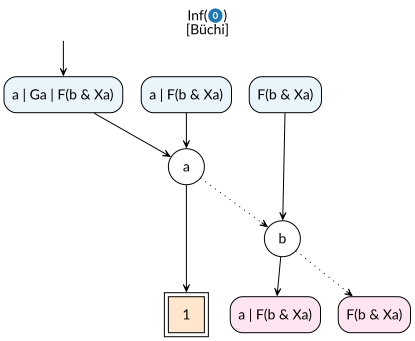

In [37]:
t4

And now we can minimize this like a DFA:

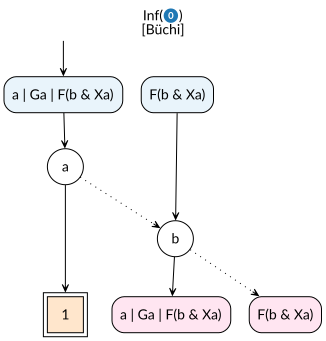

In [38]:
spot.minimize_mtdswa(t4)

Here is a larger example:

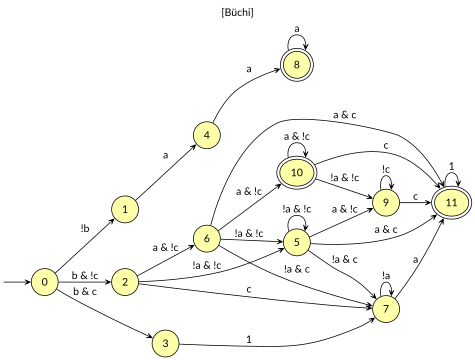

In [39]:
t5 = spot.obligation_to_mtdswa('XXFa & ((b & Fc) | XGa)')
display(t5.as_twa(True, False), t5.show('0'))

What is visible in the output above is that states 1, 4, and 8, could be merged after changing the acceptance of 1 and 4.  Without that, Moore's algorithm will not reduce anything:

In [40]:
print(t5.num_roots(), "roots, minimized to", spot.minimize_mtdswa(t5).num_roots(), "roots.")

11 roots, minimized to 11 roots.


In [41]:
t5rank = spot.loding_weak_ranking(t5, True); t5rank

(3, 1, 3, 2, 1, 2, 3, 2, 1, 2, 3)

In [42]:
t5.show("0")

11 roots, minimized to 9 roots.


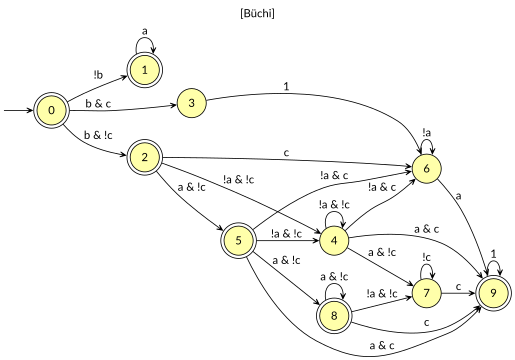

In [43]:
t5m = spot.minimize_mtdswa(t5)
print(t5.num_roots(), "roots, minimized to", t5m.num_roots(), "roots.")
display(t5m.show('0'), t5m.as_twa(True, False))

While this is not mentionned in Löding's paper, the ranking computed by `loding_weak_ranking` can be used to speed up Moore's minimization by interpreting it as the initial partition of the states.  Since the ranking is related both to the acceptance of the state, and to the number of alternation between accepting and rejecting SCCs that be reached from there, two states can only be merged if they have the same rank.

In [44]:
t5m = spot.minimize_mtdswa(t5, t5rank)  # <- initial partition given as second argument.
print(t5.num_roots(), "roots, minimized to", t5m.num_roots(), "roots.")
# The result is the same as above.

11 roots, minimized to 9 roots.


# Converting sinks to states or constants

Earlier we said that the implemented minimization does not work well if accepting and rejecting sinks are represented as constants, because the minimization only focuses on merging states.  The `sinks_as_states()` and `states_as_sinks()` rewrites the MTBDDs to change that representation.

'before'

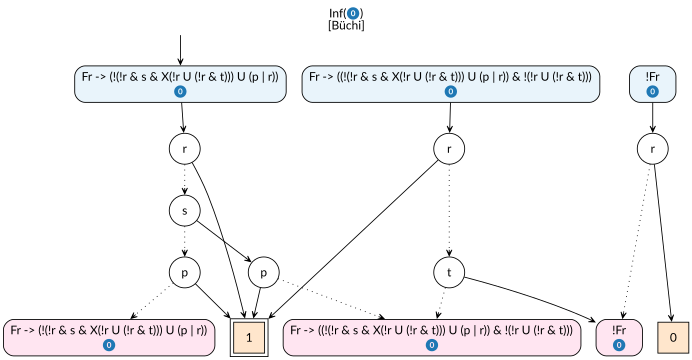

'after'

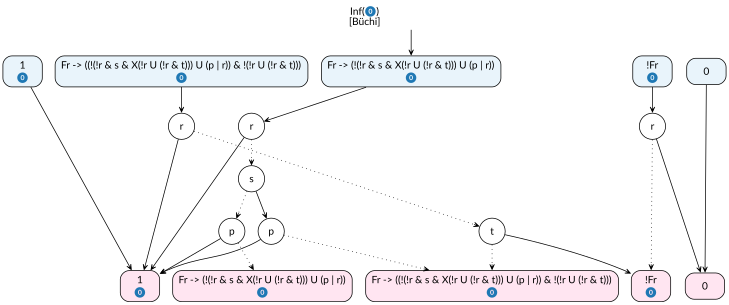

In [45]:
display("before", am)
am.sinks_as_states(); 
display("after", am)

In [46]:
am.sinks_as_constants(); am.show('s')

Replacing constants by states my require changing the acceptance condition...

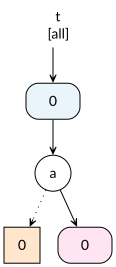

In [47]:
a1 = spot.dtwa_to_mtdswa(spot.translate('Ga', 'det', xargs="new-oblig=0")); a1

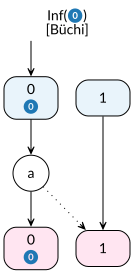

In [48]:
a1.sinks_as_states(); a1

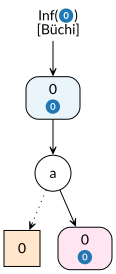

In [49]:
# Coming back to constants do not change the acceptance condition back
a1.sinks_as_constants(); a1

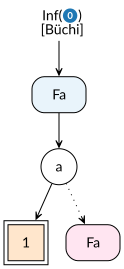

In [50]:
a2 = spot.obligation_to_mtdswa('Fa'); a2

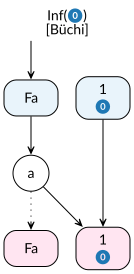

In [51]:
a2.sinks_as_states(); a2

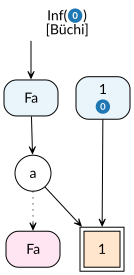

In [52]:
# The optional argument asks to uses constants, but without removing the original sink states.
a2.sinks_as_constants(True); a2

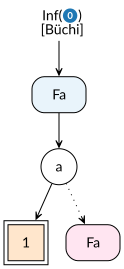

In [53]:
a2.sinks_as_constants(); a2

Here is a case where the minimization fails because the sinks are constants instead of states.  (Using `loding_weak_ranking` would not help here, as there are no transient states.)

In [54]:
o1 = spot.obligation_to_mtdswa('Ga | F!a')
o1m = spot.minimize_mtdswa(o1)
display_inline(o1, o1m)

In [55]:
# Switch to sinks to minimize
o1.sinks_as_states()
o1m = spot.minimize_mtdswa(o1)
display_inline(o1, o1m)
# Then back to constants if desired
o1.sinks_as_constants()
o1m.sinks_as_constants()
display_inline(o1, o1m)

# Comparing obligation->minimal WDBA pipelines

New version of the pipeline, using data structures and algorithms developped above:

- translate obligation to MTSWA
- convert sinks to states
- compute Löding ranking and fix the acceptance of the transient states
- minimize using the ranking as initial partition.

In [56]:
def oblig2minwdba_mtdswa(f):
    aut = spot.obligation_to_mtdswa(f)
    aut.sinks_as_states()
    ranks = spot.loding_weak_ranking(aut, True)
    aut = spot.minimize_mtdswa(aut, ranks)
    return aut

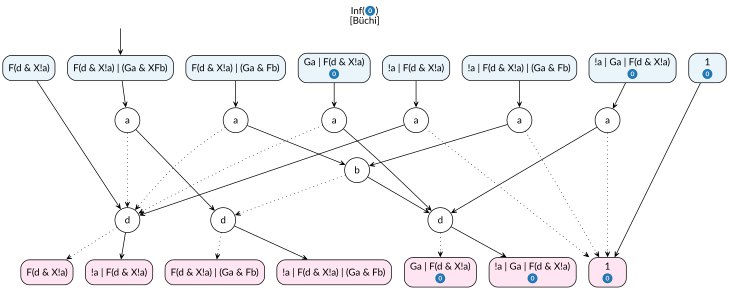

In [57]:
oblig2minwdba_mtdswa('Ga & X(Fb) | F(d & X!a)')

The old pipeline does a bit more:
- cheap simplification of the LTL formula
- convert to non-deterministic TGBA using a single color (different automaton representation, different translation algorithm)
- determinization by the powerset construction (using a product with the original automaton to recover accepting states)
- fix color of transient states using Löding's algorithm (different implementation)
- Moore minimization (different implementation, and not using the ranking as initial partition)

Keep in mind that the two pipelines construct equivalent automata with different representations.

In [58]:
def oblig2minwdba_old(f):
    return spot.translate(f, 'det', 'complete', 'low',
                          # Disable some specific preprocessings for fairer comparions.
                          # Eventually, the new translation will benefit from those as well.
                          xargs='relabel-bool=0,relabel-overlap=0,ltl-split=0,new-oblig=0')

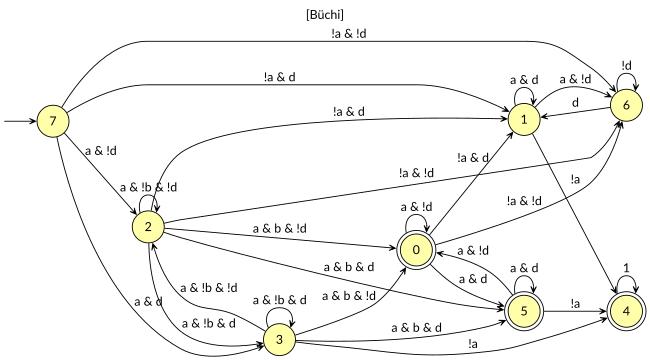

In [59]:
oblig2minwdba_old('Ga & X(Fb) | F(d & X!a)')

The `new-oblig=1` option, which is actually the default, allors `translate()` to return a TwA that has been translated using the MTDSWA-based contruction.  The minimized MTDSWA is then converted into the TwA class.  So the overhead of `oblig2minwdba_new()` over `oblig2minwdba_mtdswa()` is just the translation to MTDSWA.

In [60]:
def oblig2minwdba_new(f):
    return spot.translate(f, 'det', 'complete', 'low',
                          # Disable some specific preprocessings for fairer comparions.
                          # Eventually, the new translation will benefit from those as well.
                          xargs='relabel-bool=0,relabel-overlap=0,ltl-split=0,new-oblig=1')

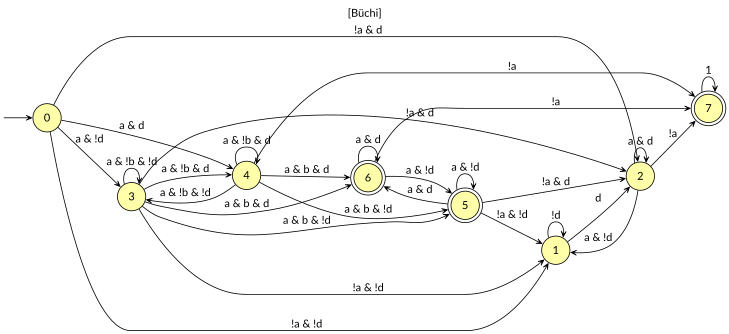

In [61]:
oblig2minwdba_new('Ga & X(Fb) | F(d & X!a)')

⚠️**BIG WARNING**⚠️ The comparison below cannot be taken very seriously because all translations will share the same BDD cache.   So when testing scalable patterns it is very likely that some BDD operation can be cached between patterns.  Some more serious benchmark (still showing trends comparable to those seen here) is included in a submitted paper.

In [62]:
from timeit import default_timer as timer

def compare(f):
    f = spot.formula(f) # parse it once
    f2 = str(f)
    t1 = timer()
    a_new = oblig2minwdba_mtdswa(f)
    t2 = timer()
    a_new2 = oblig2minwdba_new(f)
    t3 = timer()
    a_old = oblig2minwdba_old(f)
    t4 = timer()
    if len(f2) > 60: f2 = f2[:59] + "…"
    n_new = a_new.num_states()
    n_new2 = a_new2.num_states()
    n_old = a_old.num_states()
    print(f"{t2-t1:6.3f}s {t3-t2:6.3f}s {t4-t3:6.3f}s  {n_new:6}   {f2}")
    assert n_old == n_new 
    assert n_new == n_new2
    if n_old < 2000: # Don't verify the automata big automata to save time.
        assert spot.are_equivalent(a_new.as_twa(True), a_old)
        assert spot.are_equivalent(a_new2, a_old)

In [63]:
import spot.gen as gen

print("-------- time -------- |        |")
print("   new     new     old |        |")
print("(MTDSWA)  (TwA)   (TwA)| states | formula")
for pat in ((gen.LTL_AND_F, 6, 10), 
            (gen.LTL_CCJ_ALPHA, 4, 8),
            (gen.LTL_CCJ_BETA, 16, 20),
            (gen.LTL_R_LEFT, 9, 13),
            (gen.LTL_R_RIGHT, 11, 15),
            (gen.LTL_U_LEFT, 6, 10),
            (gen.LTL_U_RIGHT, 10, 14),
            (gen.LTL_TV_F1, 5, 9),
            (gen.LTL_TV_G1, 5, 9),
            (gen.LTL_TV_F2, 5, 9),
            (gen.LTL_TV_G2, 5, 9),
            (gen.LTLF_CHOMP_MEALY, 1, 1),
            (gen.LTLF_CHOMP_MEALY, 2, 2),
            (gen.LTLF_CHOMP_MEALY, 3, 2),  # 3x3 is too big for 32-bit architectures
            gen.LTL_DAC_PATTERNS,
            (gen.LTL_KR_N_DELTA1, 1, 3),
            (gen.LTL_KR_NLOGN_DELTA1, 1, 3),
            ):
    if type(pat) is tuple:
        name=f"{gen.ltl_pattern_name(pat[0])} {pat[1]}{'…' if pat[1] < pat[2] else ','}{pat[2]}"
    else:
        name=f"{gen.ltl_pattern_name(pat)}"
    print(f"                               -- {name}")
    for f in gen.ltl_patterns(pat):
        if f.is_syntactic_obligation(): # to filter the DAC patterns
            compare(f)

-------- time -------- |        |
   new     new     old |        |
(MTDSWA)  (TwA)   (TwA)| states | formula
                               -- and-f 6…10
 0.000s  0.000s  0.005s      64   Fp1 & Fp2 & Fp3 & Fp4 & Fp5 & Fp6
 0.001s  0.001s  0.013s     128   Fp1 & Fp2 & Fp3 & Fp4 & Fp5 & Fp6 & Fp7
 0.001s  0.001s  0.063s     256   Fp1 & Fp2 & Fp3 & Fp4 & Fp5 & Fp6 & Fp7 & Fp8
 0.002s  0.004s  0.311s     512   Fp1 & Fp2 & Fp3 & Fp4 & Fp5 & Fp6 & Fp7 & Fp8 & Fp9
 0.007s  0.016s  4.206s    1024   Fp1 & Fp2 & Fp3 & Fp4 & Fp5 & Fp6 & Fp7 & Fp8 & Fp9 & Fp10
                               -- ccj-alpha 4…8
 0.000s  0.000s  0.006s      25   F(p1 & F(p2 & F(p3 & Fp4))) & F(q1 & F(q2 & F(q3 & Fq4)))
 0.000s  0.000s  0.035s      36   F(p1 & F(p2 & F(p3 & F(p4 & Fp5)))) & F(q1 & F(q2 & F(q3 & …
 0.000s  0.000s  0.207s      49   F(p1 & F(p2 & F(p3 & F(p4 & F(p5 & Fp6))))) & F(q1 & F(q2 &…
 0.000s  0.001s  1.506s      64   F(p1 & F(p2 & F(p3 & F(p4 & F(p5 & F(p6 & Fp7)))))) & F(q1 …
 0.001s  0.001s 10.

The difference between the two NEW versions is mostly due to the automaton representation.  In the second column, the MTDSWA has to be converted into a TwA, and this conversion (which requires enumerating the paths in the MTBDDs, and creating labels for each of those) has a significant overhead.  However, even with this overhead, the new approach outperforms the old one most of the time.

It is interesting to see that there are a two families where it is slower, namely, `kr-n-delta1` and `kr-nlogn-delta1`.  These are linear and quasilinear formulas for which the minimal DBA is at least doubly exponential; i.e., the worst case of the translation.

I've investigated the behavior of the old a new pipelines on `kr-nlogn-delta1=3`:
- The old pipeline builds a 1381-state NBA that is then determinized into a 6454-state DBA, and minimized to 6207 states.
- The new pipeline builds a 7559-state DBA that is then minimized to 6207 states.

Seeing that the new pipeline was spending a lot of time running propositional equivalence on all the LTL formulas that label BDD leaves, I've worked on that a bit.  Adding some missing caches to propositional equivalence, as well as doing the prop.eq. in a second pass after the computation of $\mathit{tr}(\cdot)$ instead of doing it during the computation on each intermediate terminal and a few shortcuts.  This actually reduced the runtime significantly, but as seen above, this is still very large.  Currently, propositional equivalence in the new pipeline (to MTDSWA) amounts for 65% of the time spent translating `kr-nlogn-delta1=3`.  The translation of the old pipeline (Couvreur's) also performs some kind of propositional equivalence, but I think it is helped by two factors:
- it is building an NBA with 1381 states, so the set of LTL formulas on which propositional equivalence has run is much smaller
- it builds BDDs that are similar to the MTBDD we build, except that Couvreur replaces the LTL-labeled terminals by the BDD that we use for propositional encoding.  This means that the LTL *formulas* that label destination states need only be reconstructed at the end of the translation of the BDD representing the each state, not for each intermediate computation...

# Synthesis

If we want to solve synthesis with Mealy semantics, we can declare input variables before output variables, and mark output variables as "controllable".  This way the automaton can be interpreted as a game:

In [64]:
f = 'G(a <-> X!a) | F(b & Xa)'
with spot.bdd_dict_preorder("b") as d:
    aut = spot.obligation_to_mtdswa(f, dict=d)
    aut.set_controllable_variables(['a'])
    display(aut.show('s'))

The synthesis algorithm actually solves the game while building the automaton, hopefully avoiding the computation of some states.  The following example shows some of the intermediate step of the construction.

The constructed automaton is explored using a DFS that track strongly connected components.  When backtracking from an SCC any state that is undetermined (i.e., not yet marked as winning for either player) is marked according to the nature of the SCC: if the SCC is accepting any cycle it contains is winning for the output player, if the SCC is rejecting, any cycle it contains is winning for the input player.  The algorithm terminates as soon the the initial state is determined.

In the following intermediate outputs,
- dashed states haven't been translated yet,
- green nodes are winning for the output player,
- red nodes are winning for the input player,
- the yellow state is the next one to work on.

States in the debug output are also marked with <font color="#33A02C">❹</font> or <font color="#E31A1C">❺</font> when their corresponding terminals are winning for input or output.  This is a workaround to a limitation of our Graphviz printer that we can only color BDD nodes (including terminals) but the "state labels" that point to the roots of those BDDs.  All this cosmetic work is of course performed only when the `debug` option is given.

Note also that contrary to the output above, the acceptance of each state is not computed during the on-the-fly.  We only need to compute the acceptance of one state per SCC at the moment where we remove it.  Ultimately, all losing states will be removed from the automaton, and any infinite path in the remaining automaton will be a valid controller.

step 0


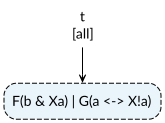

step 1


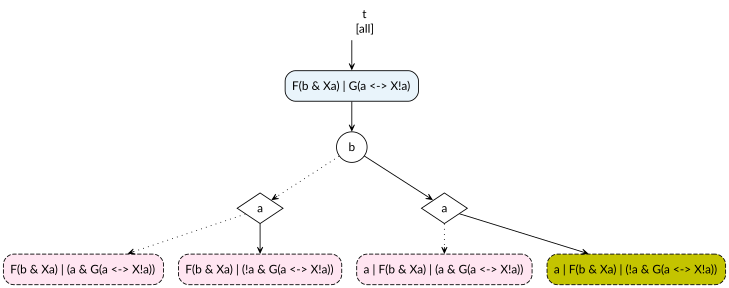

step 2


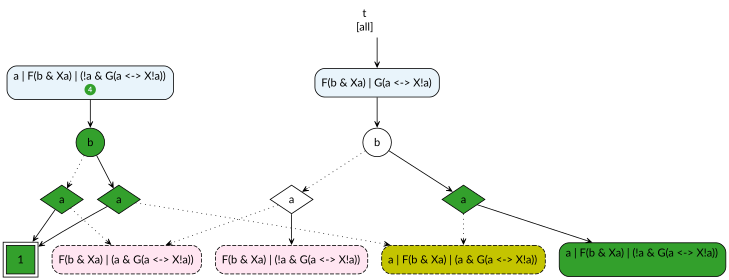

step 3


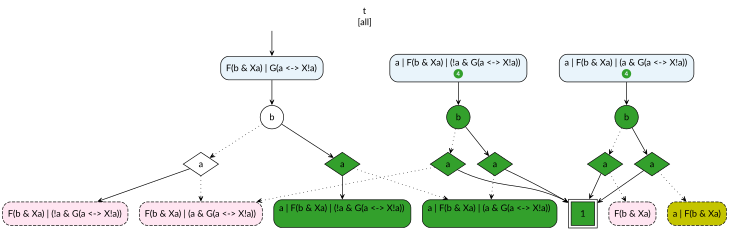

step 4


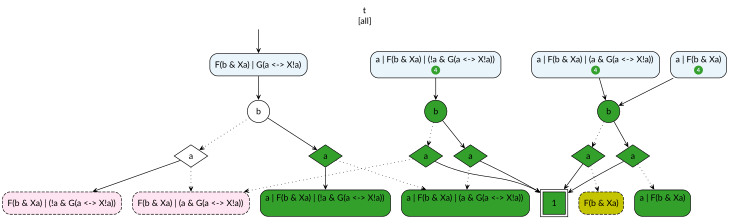

step 5


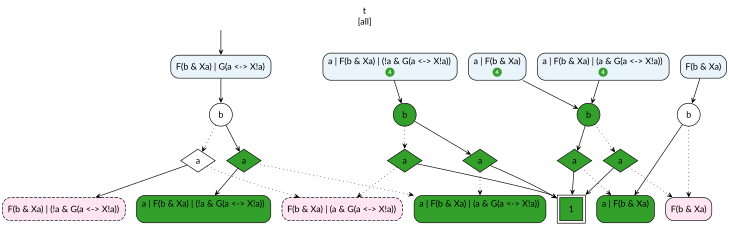

step 7


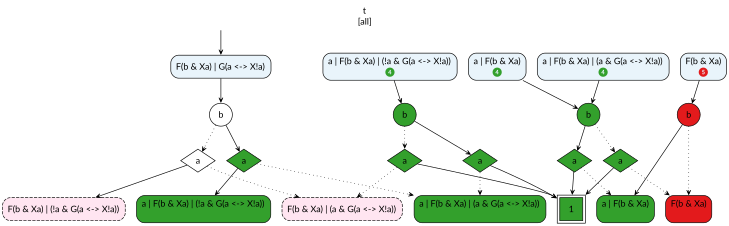

step 9


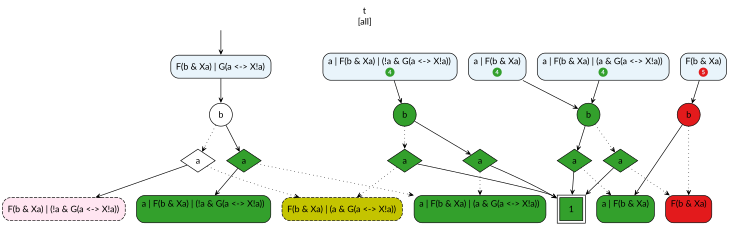

step 10


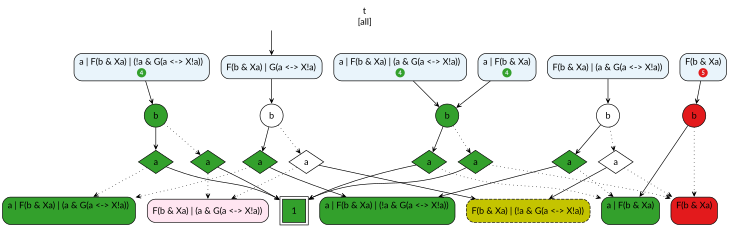

step 11


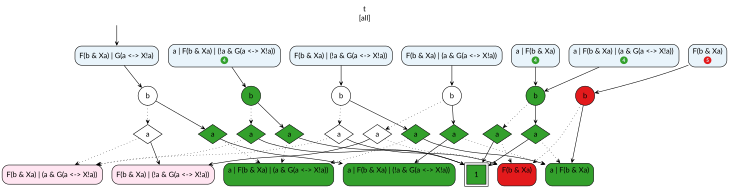

step 14


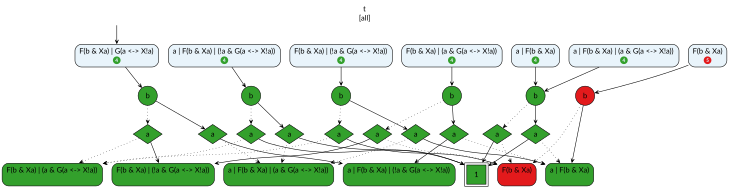

In [65]:
with spot.bdd_dict_preorder("b") as d:
    for step in (0,1,2,3,4,5,7,9,10,11,14):
        print("step", step)
        display(spot.obligation_synthesis(f, ['a'], dict=d, debug=step))

Each step above represents one iteration of the DFS loop, which is either considering one possible successor for the current state (if a state was highlighted in yellow at step N, it will be the state developped at step N+1), or a backtrack of the DFS (if no state is highlighted at step N, next step is a backtrack).  The entir

Currently the output of `spot.obligation_synthesis`, without the `debug` option, is a crude output obtained remplacing all non-winning nodes (not green) by `bddfalse`, and for each output node (diamonds) that has two winning successors, selecting one successor by redirecting the other to `bddfalse` (the backpropagation code simply remembers the edge that contributed to marking a node as winning).  Probably we could improve that.

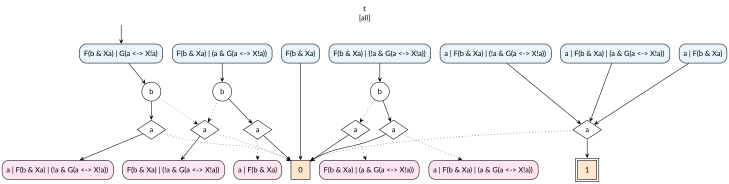

In [66]:
with spot.bdd_dict_preorder("b") as d:
    aut = spot.obligation_synthesis(f, ['a'], dict=d)
display(aut)

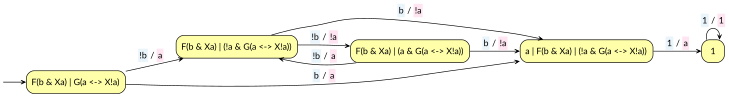

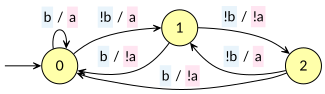

In [67]:
m = spot.mtdswa_strategy_to_mealy(aut)
display(m, spot.reduce_mealy(m))

Here is the same specification, but with input and output swapped, so that it becomes unrealizable.  In this case, we can see the algorithm abort before visiting all states.

step 0


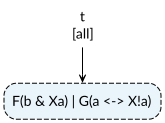

step 1


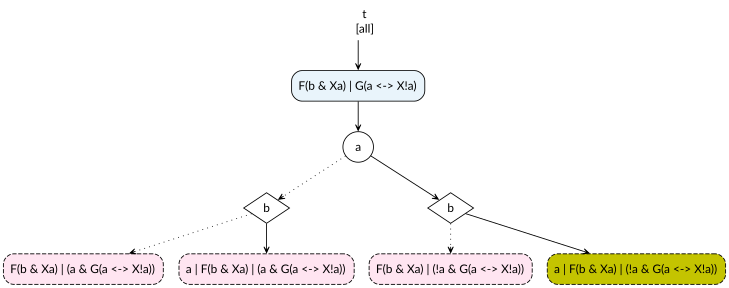

step 2


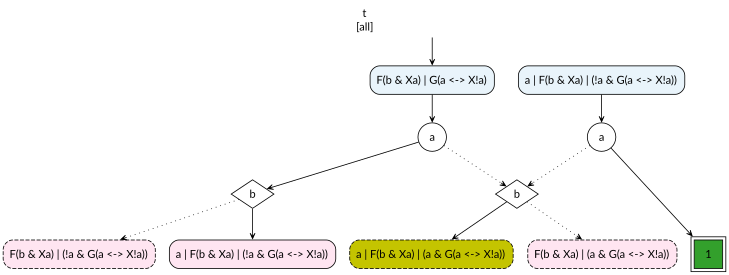

step 3


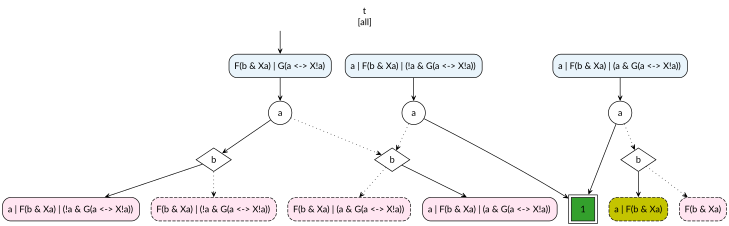

step 4


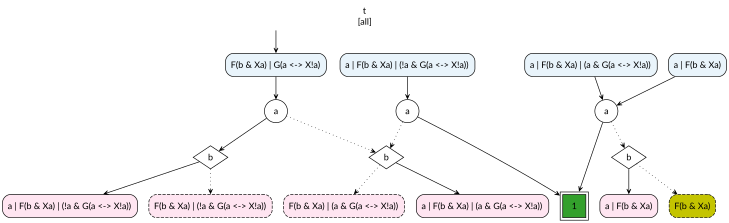

step 5


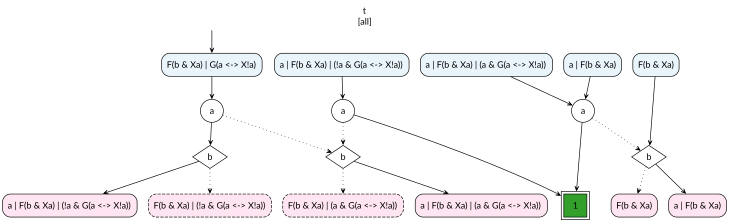

step 7


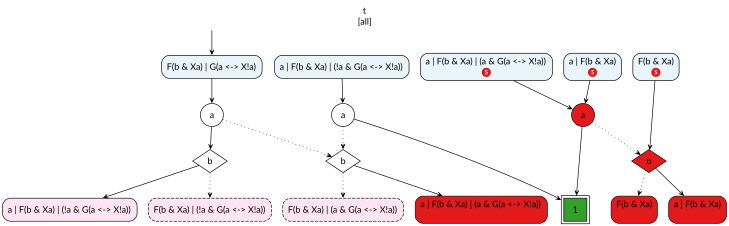

step 9


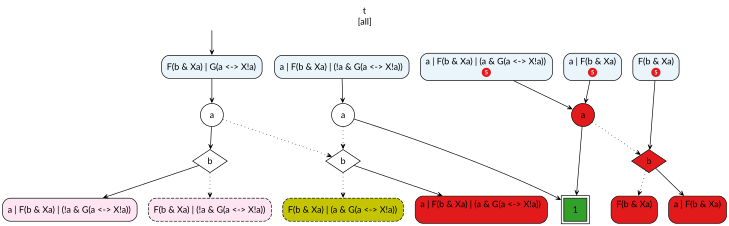

step 10


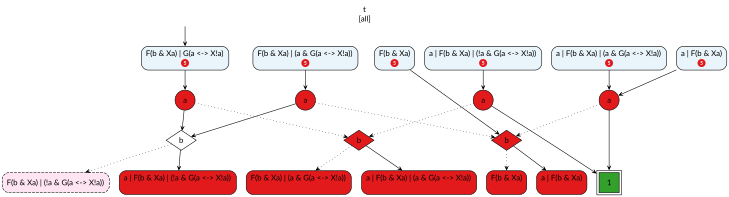

In [68]:
with spot.bdd_dict_preorder("a") as d:
    for step in (0,1,2,3,4,5,7,9,10):
        print("step", step)
        display(spot.obligation_synthesis(f, ['b'], dict=d, debug=step))

The full algorithm without debug mode, simply returns an automaton with a single state equal to `bddfalse` (and acceptance `f`) in case the specification is not realizable.

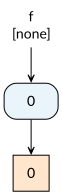

In [69]:
with spot.bdd_dict_preorder("a") as d:
    aut = spot.obligation_synthesis(f, ['b'], dict=d)
display(aut)

Here is another example, taken from SyntComp's `tsl_paper/OneCounterInRangeA2.tlsf`.

step 0


step 1


step 2


step 3


step 4


step 5


step 6


step 9


output


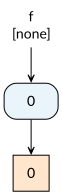

In [70]:
g = 'G!((o1 & !(o0 | o2)) <-> (!o1 & !((!o0 & o2) <-> (o0 & !o2)))) & ((i2 & G!(i0 & i1) & G((i2 & o0) -> Xi2) & G((i4 & o2) -> Xi2)) -> (G(o2 <-> (i1 & i4)) & G(o1 <-> (i0 & i3)) & Gi2))'
with spot.bdd_dict_preorder("i0", "i1", "i2", "i3", "i4") as d:
    for step in (0,1,2,3,4,5,6,9):
        print("step", step)
        aut = spot.obligation_synthesis(g, ['o0', 'o1', 'o2'], dict=d, debug=step)
        display(aut.show('0'))
    print("output")
    aut = spot.obligation_synthesis(g, ['o0', 'o1', 'o2'], dict=d)
    display(aut)